### Загрузка и обработка данных

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd()))

import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from Modules.panel_utils import (
    detect_outlier_regions_iqr,
    run_panel_unit_root_tests,
)
from Modules.seasonal_adjustment import (
    run_friedman_seasonality_tests,
)


In [2]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################
df_RF = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data_RF')
df_reg = pd.read_excel('База данных_рег и фед показатели.xlsx',skiprows=1 , sheet_name = 'data')
households_structure = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', skiprows=1, sheet_name = 'Фин пол ДХ')
households_loans = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', sheet_name = 'КЖН (рейтинг)')
funds_coefficient = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', skiprows=2, sheet_name = 'Коэф фондов')

mon_schock = 'mon_shock_dataset.pkl'
old_clustering = 'region_cluster_dataset.pkl'
hank_clustering = 'region_cluster_hank_dataset.pkl'
new_clustering = 'region_cluster_new_dataset.pkl'
with open(mon_schock, 'rb') as f:
    df_shocks = pickle.load(f)
with open(old_clustering, 'rb') as f:
    df_region_cluster_old = pickle.load(f)
with open(hank_clustering, 'rb') as f:
    df_region_cluster_hank = pickle.load(f)
with open(new_clustering, 'rb') as f:
    df_region_cluster_new = pickle.load(f)
# Преобразование даты 
df_shocks['Date'] = pd.to_datetime(df_shocks['Date'])
df_RF['Date'] = pd.to_datetime(df_RF['Date'])
df_RF = df_RF.sort_values('Date')
df_reg['Date'] = pd.to_datetime(df_reg['Date'])
df_reg = df_reg.sort_values(['Num_reg','Date'])
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

In [3]:
###############################
# АНАЛИЗ ПАНЕЛЬНЫХ ДАННЫХ
###############################

#  ДОБАВЛЯЕМ КЛАСТЕРЫ 
df_reg = df_reg.merge(df_region_cluster_old, on='Region', how='left')
df_reg = df_reg.merge(df_region_cluster_hank, on='Region', how='left')
df_reg = df_reg.merge(df_region_cluster_new, on='Region', how='left')

# ============ ФЕДЕРАЛЬНЫЕ ПЕРЕМЕННЫЕ ============
df_reg = df_reg.merge(df_shocks[['Date', 'Mon_Shock']], on='Date', how='left')

df_RF.rename(columns={'exc_rate': 'Exc_rate', 'exc_rate_diff': 'd_Ex_Rate'}, inplace=True)

df_rf_extra = df_RF[['Date', 'ROISFIX', 'MIACR', 'Covid_dum', 'Sank_dum',
                'Exc_rate', 'Bonds_Rate_Correct_5Y', 'Inflation_Expectations',
                'MaP_Announcement', 'MaP_Tight_Announcement', 'MaP_Ease_Announcement',
                'MaP_Fact','MaP_Tight_Fact', 'MaP_Ease_Fact','REER', 'Oil_p', 'MaP_Announcement', 'MaP_Fact']].copy()

                     
df_reg = df_reg.merge(df_rf_extra, on='Date', how='left')
df_reg.rename(columns={'CPI': 'CPI_reg'}, inplace=True)

#Расчетные показатели
df_reg['Oil_p_share_mining'] = df_reg['Oil_p'] * df_reg['Share_mining']

# Создаем лаги
df_reg['D_top5_rozn_lag1'] = df_reg.groupby('Region')['D_top5_rozn'].shift(1)
df_reg['CPI_reg_lag1'] = df_reg.groupby('Region')['CPI_reg'].shift(1)
df_reg['Def_Zadolg_Fl_lag1'] = df_reg.groupby('Region')['Def_Zadolg_Fl'].shift(1)
df_reg['Def_Zadolg_Mort_lag1'] = df_reg.groupby('Region')['Def_Zadolg_Mort'].shift(1)
df_reg['Def_Zadolg_ConsCred_lag1'] = df_reg.groupby('Region')['Def_Zadolg_ConsCred'].shift(1)
df_reg['Cap_to_assets_lag1'] = df_reg.groupby('Region')['Cap_to_assets'].shift(1)

### Преобразование данных

In [4]:
# Сортировка
df_reg = df_reg.sort_values(['Region', 'Date']).copy()
df_RF = df_RF.sort_values(['Date']).copy()

# ============ ЛОГАРИФМИРОВАНИЕ ============ #

loan_vars = ['New_Loans_Fl', 'New_Loans_Mort', 'New_Loans_ConsCred', 'Fin_Dostup']

for var in loan_vars:
    if var in df_reg.columns:
        df_reg[f'ln_{var}'] = np.log(df_reg[var])
        
ln_loan_vars = [f'ln_{var}' for var in loan_vars if f'ln_{var}' in df_reg.columns]


# ============ СОЗДАНИЕ ПЕРВЫХ РАЗНОСТЕЙ  ============ #

# Разности для логарифмов 
for var in ln_loan_vars:
    d_var = f'd_{var}'
    df_reg[d_var] = df_reg.groupby('Region')[var].diff()

################################
# Разности переменных регионов #
################################

diff_vars_reg = ['Int_Rate_FL', 'Int_Rate_Mort', 'Int_Rate_ConsCred', \
            'Mon_Shock', 'ROISFIX', 'MIACR','CPI_reg', \
            'ln_New_Loans_Fl', 'ln_New_Loans_Mort', 'ln_New_Loans_ConsCred']

for var in diff_vars_reg:
    d_var = f'd_{var}'
    df_reg[d_var] = df_reg.groupby('Region')[var].diff()

#################################
# Разности федеральных переменных
#################################

df_RF = df_RF.sort_values(['Date'])

diff_vars_fed = ['Key_Rate', 'ROISFIX', 'MIACR', 
                'IBC_constr_fed', 'IBC_torg_fed', 'IBC_auto_fed',]

for var in diff_vars_fed:
    d_var = f'd_{var}'
    df_RF[d_var] = df_RF[var].diff()


# Разделим шоки на позитивные и негативные
# Mon_Shock
df_reg['d_Mon_Shock_neg'] = df_reg['d_Mon_Shock'].where(df_reg['d_Mon_Shock'] < 0, 0)
df_reg['d_Mon_Shock_pos'] = df_reg['d_Mon_Shock'].where(df_reg['d_Mon_Shock'] > 0, 0)
# Разность ROISFIX 
df_reg['d_ROISFIX_neg'] = df_reg['d_ROISFIX'].where(df_reg['d_ROISFIX'] < 0, 0)
df_reg['d_ROISFIX_pos'] = df_reg['d_ROISFIX'].where(df_reg['d_ROISFIX'] > 0, 0)
# Разность MIACR 
df_reg['d_MIACR_neg'] = df_reg['d_MIACR'].where(df_reg['d_MIACR'] < 0, 0)
df_reg['d_MIACR_pos'] = df_reg['d_MIACR'].where(df_reg['d_MIACR'] > 0, 0)


#  Создаем взаимодействия для переменных процентных ставок
map_vars_int = ['d_Mon_Shock',
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'd_ROISFIX',
    'd_ROISFIX_neg',
    'd_ROISFIX_pos',
    'd_MIACR',
    'd_MIACR_neg',
    'd_MIACR_pos',
]

z_vars_int = [
    'Covid_dum',
    'Sank_dum',
    'Cluster_1',
    'Cluster_2'
]
for m in map_vars_int:
    for z in z_vars_int:
        col_name = f"{m}_{z}"
        df_reg[col_name] = df_reg[m] * df_reg[z]


#  Создаем взаимодействия для переменных макропру
map_var_makro = [
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
]

z_vars_makro = [
    'D_top5_rozn_lag1',
    'Cap_to_assets_lag1',
    'Cluster_new_1',
    'Cluster_new_2',
    'Cluster_new_3'
]
for m in map_var_makro:
    for z in z_vars_makro:
        col_name = f"{m}_{z}"
        df_reg[col_name] = df_reg[m] * df_reg[z]


In [5]:
# СПИСОК ПЕРЕМЕННЫХ
all_vars = {
'conscred_vars' : [
    'd_Int_Rate_ConsCred',          # Зависимая переменная
    'Int_Rate_ConsCred',
    'New_Loans_ConsCred',           # Выдача
    'New_Loans_ConsCred_mom',
    'New_Loans_Fl',
    'New_Loans_Fl_mom',
    'Zadolg_ConsCred',              # Задолженность
    'Zadolg_ConsCred_mom', 
    'Zadolg_Fl',
    'Zadolg_Fl_mom',
    'Def_Zadolg_ConsCred',          # Дефицит задолж
    'Def_Zadolg_Fl',
    'Cred_nagr',                    # Переменные состояния финансового рынка
    'Fin_Dostup',
    'D_top5_rozn',
    'Zakred',
    'Exc_rate',                     # Переменные ожиданий
    'Bonds_Rate_Correct_5Y',
    'Inflation_Expectations',
    #
    'Mon_Shock',                    # Шоки
    'd_Mon_Shock',
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'ROISFIX',
    'MIACR',
    'Covid_dum',                    # Дамми
    'Sank_dum',
    'Cluster_1',
    'Cluster_2',
],

'exog_vars' : [
    #Блок 1 - Зависимые переменные 
    'd_ln_New_Loans_Fl',
    'd_ln_New_Loans_Mort',
    'd_ln_New_Loans_ConsCred',
    #Блок 2 - Переменные интереса 
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
    #Блок 3 - характеристики фин системы
    'D_top5_rozn_lag1',
    'ln_Fin_Dostup',
    'Def_Zadolg_Fl_lag1',
    'Def_Zadolg_Mort_lag1',
    'Def_Zadolg_ConsCred_lag1',
    'Cap_to_assets_lag1',
    #Блок 4 - макроэкономический
    'CPI_reg_lag1',
    'Oil_p_share_mining',
    'REER',
    #Блок 5 - монетарный 
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'd_ROISFIX_neg',
    'd_ROISFIX_pos',
    'd_MIACR_neg',
    'd_MIACR_pos',
    #Блок 6 - кластеры
    'Cluster_new_1',
    'Cluster_new_2',
    'Cluster_new_3',
    #Блок 7 - шоки
    'Covid_dum',
    'Sank_dum'
],

'other_vars' : [
    'Int_Rate_FL',
    'Int_Rate_FL_lag1',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_Mort_lag1',
    'Int_Rate_ConsCred',
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y',
    'Cluster_1',
    'Cluster_2',
    'Cluster_HANK_1',
    'Cluster_HANK_2',
    'Cluster_HANK_3',
    'New_Loans_Progr',
    'MIACR',
    'Covid_dum',
    'Sank_dum',
    'ROISFIX'
]
}
choosed_vars = all_vars['exog_vars']
name = [key for key, value in all_vars.items() if value == choosed_vars][0][:-5]

df_reg_analys = df_reg[['Region', 'Date'] + choosed_vars].copy()
cols_for_drop = [c for c in df_reg_analys.columns if c not in ['New_Loans_Progr']]
df_reg_analys = df_reg_analys.dropna(subset=cols_for_drop)

### IQR чистка

In [6]:
print("\n" + "="*70)
print("ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR")
print("="*70)

key_vars = [x for x in choosed_vars if x not in [
    #Монетарные шоки
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'd_ROISFIX_neg',
    'd_ROISFIX_pos',
    'd_MIACR_neg',
    'd_MIACR_pos',
    #Макропру шоки
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
    #Кластеры
    'Cluster_HANK_1',
    'Cluster_HANK_2',
    'Cluster_HANK_3',
    'Cluster_1',
    'Cluster_2',
    'Cluster_new_1',
    'Cluster_new_2',
    'Cluster_new_3',
    #Санкции + ковид
    'Covid_dum',
    'Sank_dum',
    
    'd_IBC_constr',
    'd_IBC_torg',
    'd_IBC_auto',
    ]
]


# АНАЛИЗ РЕГИОНОВ ПО IQR
region_quality_iqr = detect_outlier_regions_iqr(df_reg_analys, key_vars, min_obs=60, max_na_pct=0.3)

print(f"\n АНАЛИЗ {len(region_quality_iqr)} РЕГИОНОВ (IQR)")
print(region_quality_iqr.to_string(index=False))

# СТАТИСТИКА
exclude_count = len(region_quality_iqr[region_quality_iqr['Status'] == 'EXCLUDE'])
keep_count = len(region_quality_iqr) - exclude_count

print(f"\n СТАТИСТИКА:")
print(f"Всего регионов: {len(region_quality_iqr)}")
print(f"Исключено: {exclude_count} ({exclude_count/len(region_quality_iqr)*100:.1f}%)")
print(f"Оставлено: {keep_count}")

# СПИСОК ХОРОШИХ РЕГИОНОВ
good_regions_iqr = region_quality_iqr[region_quality_iqr['Status'] == 'KEEP']['Region'].tolist()

# СОХРАНЕНИЕ СПИСКА РЕГИОНОВ
with Path('filter_for_cluster.pkl').open("wb") as saved:
    pickle.dump(good_regions_iqr, saved)

# ФИЛЬТРАЦИЯ ДАННЫХ
df_reg_analys= df_reg_analys[df_reg_analys['Region'].isin(good_regions_iqr)].copy()
print(f"\n Форма после очистки (IQR): {df_reg_analys.shape}")


ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR

 АНАЛИЗ 65 РЕГИОНОВ (IQR)
                    Region  N_obs NA_pct  IQR_outliers IQR_pct Reasons Status
            Алтайский край     80   0.0%            12   15.0%           KEEP
          Амурская область     80   0.0%            10   12.5%           KEEP
     Архангельская область     80   0.0%            12   15.0%           KEEP
      Астраханская область     80   0.0%             8   10.0%           KEEP
      Белгородская область     80   0.0%            11   13.8%           KEEP
          Брянская область     80   0.0%             8   10.0%           KEEP
      Владимирская область     80   0.0%             8   10.0%           KEEP
     Волгоградская область     80   0.0%             8   10.0%           KEEP
       Вологодская область     80   0.0%             9   11.2%           KEEP
       Воронежская область     80   0.0%             8   10.0%           KEEP
        Забайкальский край     80   0.0%             6    7.5%           KEEP
     

### ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ

In [7]:
descriptive_df = df_reg_analys.drop(columns=['Date', 'Region', #'Int_Rate_ConsCred_lag1'
                                            ], axis = 1, inplace=False)


desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
                          Среднее  Медиана  ст. откл.    Мин.     Макс.
d_ln_New_Loans_Fl           0.010    0.040      0.171  -0.936     0.738
d_ln_New_Loans_Mort         0.011    0.076      0.364  -1.826     1.162
d_ln_New_Loans_ConsCred     0.010    0.026      0.149  -0.973     0.814
MaP_Tight_Announcement      0.212    0.000      0.409   0.000     1.000
MaP_Ease_Announcement       0.138    0.000      0.344   0.000     1.000
MaP_Tight_Fact              0.212    0.000      0.409   0.000     1.000
MaP_Ease_Fact               0.138    0.000      0.344   0.000     1.000
D_top5_rozn_lag1            0.772    0.770      0.060   0.614     0.939
ln_Fin_Dostup               2.948    2.927      0.237   2.348     3.869
Def_Zadolg_Fl_lag1          4.236    4.199      0.833   2.137     8.234
Def_Zadolg_Mort_lag1        0.580    0.484      0.382   0.043     3.837
Def_Zadolg_ConsCred_lag1    7.514    7.466      1.170   3.539    12.338
Cap_to_asse

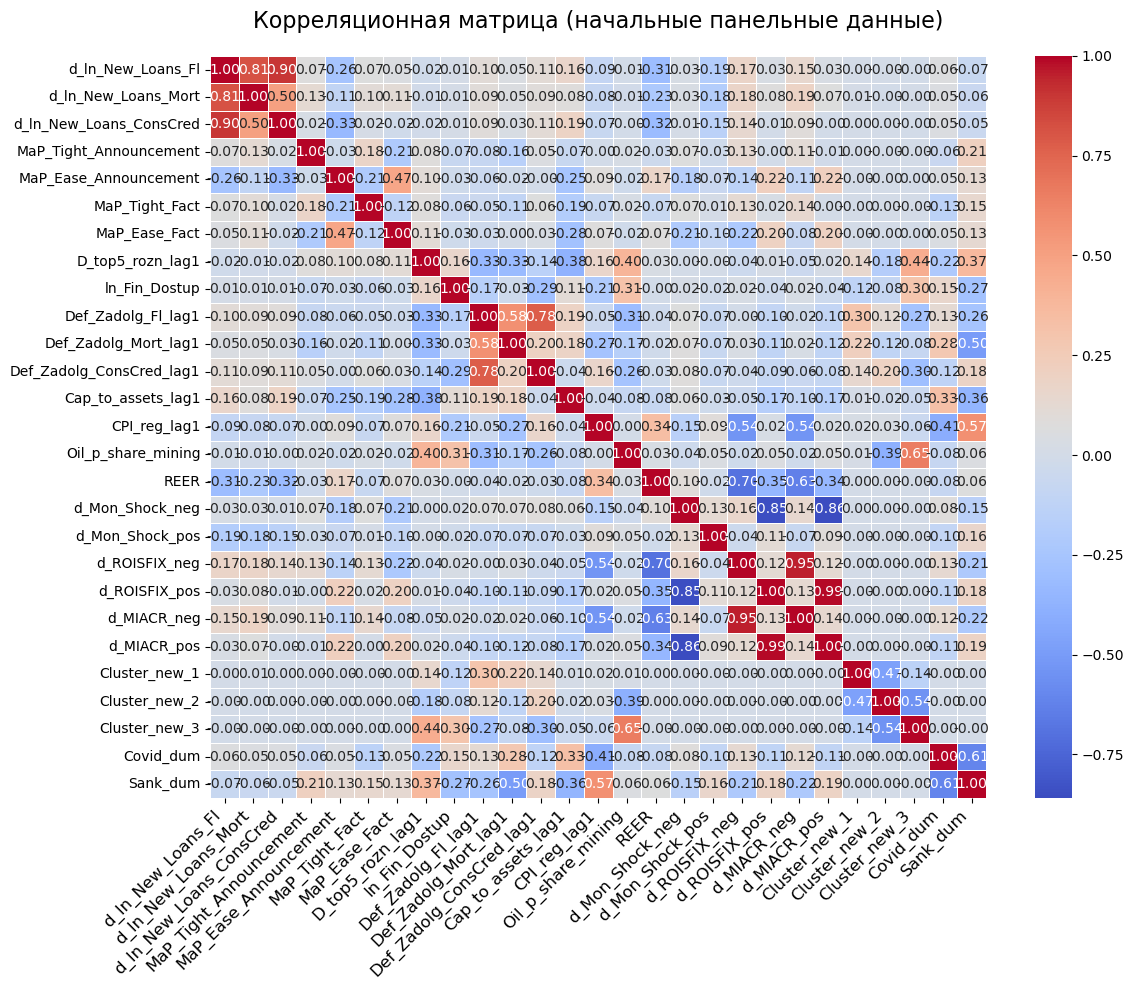

In [8]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (начальные панельные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

### Тест Фридмана на сезонность

In [ ]:
# # Extra diagnostics after Friedman test
# from Modules.seasonal_adjustment import run_seasonal_diagnostics

# series_list = [
#     'Inflation_Expectations',
#     'Ent_conf_ind_mining',
#     'Ent_conf_ind_manufactoring'
# ]

# for col in series_list:
#     if col in df_RF.columns:
#         run_seasonal_diagnostics(df_RF, 'Date', col, shock_year="2022")
#     else:
#         print(f'Missing column: {col}')


# # ####################################
# # # Сезонность есть даже с учётом шока в: Inflation_Expectations, Ent_conf_ind_manufactoring

### ===== СЕЗОННАЯ КОРРЕКТИРОВКА ДЛЯ ПАНЕЛЬНЫХ ДАННЫХ =====

In [ ]:
df_reg_analys.columns

In [ ]:
# Сезонная корректировка 
# ! Для корректировки НЕОБХОДИМО добавить новые переменные в список функции seasonal_adjust_panel_wrapper в seasonal_adjustment.py
# 'Inflation_Expectations', 'Ent_conf_ind_manufactoring', 'Ent_conf_ind_mining' потенциальные переменные
# Output_Index, IBC_constr, IBC_torg, IBC_auto, IBC_constr_fed, IBC_torg_fed, IBC_auto_fed

from Modules.seasonal_adjustment import seasonal_adjust_panel_wrapper

col_name_reg = ['Inflation_Expectations']  
df_reg_analys = seasonal_adjust_panel_wrapper(df_reg_analys, col_name_reg)

col_name_fed = ['Ent_conf_ind_manufactoring', 'Ent_conf_ind_mining', 'd_IBC_constr_fed', 'd_IBC_torg_fed', 'd_IBC_auto_fed'] 
df_RF = seasonal_adjust_panel_wrapper(df_RF, col_name_fed)


In [ ]:
# Чистка датафрейма
to_delete_columns_reg = [col for col in df_reg_analys.columns if col.endswith('_seasonal') or col.endswith('_trend')]
to_delete_columns_RF = [col for col in df_RF.columns if col.endswith('_seasonal') or col.endswith('_trend')]

df_reg_analys.drop(columns=to_delete_columns_reg, inplace=True)
df_RF.drop(columns=to_delete_columns_RF, inplace=True)

# Разность инфляционных ожиданий
df_reg_analys['d_Inflation_Expectations'] = df_reg_analys['Inflation_Expectations_adj'].diff()

### Tестирование единичных корней

In [ ]:
# # ===== ЗАПУСК ТЕСТОВ НА КОНКРЕТНЫЕ ПЕРЕМЕННЫЕ =====

# print("\n" + "="*70)
# print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ - КЛАСТЕР 1")
# print("="*70)

# # === СПИСОК ПЕРЕМЕННЫХ ДЛЯ ТЕСТИРОВАНИЯ ===
# custom_vars = [x for x in choosed_vars if x not in [
#     'Cluster_1',
#     'Cluster_2',
#     'Covid_dum',
#     'Sank_dum']
# ]

# df_reg_analys_clus_1 = df_reg_analys[df_reg_analys['Cluster_1'] == 1].copy()

# # Запуск функции с пользовательским списком переменных
# results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_1, panel_vars=custom_vars)

In [ ]:
# print("\n" + "="*70)
# print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 2")
# print("="*70)


# df_reg_analys_clus_two = df_reg_analys[df_reg_analys['Cluster_2'] == 1].copy()

# # Запуск функции с пользовательским списком переменных
# results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_two, panel_vars=custom_vars)

In [ ]:
# print("\n" + "="*70)
# print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 3")
# print("="*70)

# df_reg_analys_clus_three = df_reg_analys[(df_reg_analys['Cluster_1'] == 0) & (df_reg_analys['Cluster_2'] == 0)].copy()

# # Запуск функции с пользовательским списком переменных
# results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_three, panel_vars=custom_vars)

In [ ]:
# print("\n" + "="*70)
# print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - ВСЕ ДАННЫЕ")
# print("="*70)
# # Запуск функции с пользовательским списком переменных
# results_seasonal_adjusted_all = run_panel_unit_root_tests(df_reg_analys, panel_vars=custom_vars)

### Добавление недостающих переменных

In [9]:
# Создаем нужные лаги
lag_vars = ['d_ln_New_Loans_Fl', 
            'd_ln_New_Loans_Mort',
            'd_ln_New_Loans_ConsCred',
            'MaP_Tight_Announcement',
            'MaP_Ease_Announcement',
            'MaP_Tight_Fact',
            'MaP_Ease_Fact'
           ]
for var in lag_vars:
    lag_var = f'{var}_lag1'
    df_reg[lag_var] = df_reg[var].shift(1)
    
#добавляем переменные
missing_vars = [
            'd_ln_New_Loans_Fl_lag1',
            'd_ln_New_Loans_Mort_lag1',
            'd_ln_New_Loans_ConsCred_lag1',
            'MaP_Tight_Announcement_lag1',
            'MaP_Ease_Announcement_lag1',
            'MaP_Tight_Fact_lag1',
            'MaP_Ease_Fact_lag1',
            'MaP_Tight_Announcement_D_top5_rozn_lag1',
            'MaP_Tight_Fact_D_top5_rozn_lag1',
            'MaP_Ease_Announcement_D_top5_rozn_lag1',
            'MaP_Ease_Fact_D_top5_rozn_lag1',
            'MaP_Tight_Announcement_Cap_to_assets_lag1',
            'MaP_Tight_Fact_Cap_to_assets_lag1',
            'MaP_Ease_Announcement_Cap_to_assets_lag1',
            'MaP_Ease_Fact_Cap_to_assets_lag1',
            'MaP_Tight_Announcement_Cluster_new_1',
            'MaP_Tight_Fact_Cluster_new_1',
            'MaP_Ease_Announcement_Cluster_new_1',
            'MaP_Ease_Fact_Cluster_new_1',
            'MaP_Tight_Announcement_Cluster_new_2',
            'MaP_Tight_Fact_Cluster_new_2',
            'MaP_Ease_Announcement_Cluster_new_2',
            'MaP_Ease_Fact_Cluster_new_2',
            'MaP_Tight_Announcement_Cluster_new_3',
            'MaP_Tight_Fact_Cluster_new_3',
            'MaP_Ease_Announcement_Cluster_new_3',
            'MaP_Ease_Fact_Cluster_new_3'
]

for var in missing_vars:
    df_reg_analys[var] = df_reg[var]  

### Сохранение результатов

In [11]:
df_reg_analys.to_excel(f'Operations/{name}_reg_analys.xlsx')
df_RF.to_excel('Operations/fed_analys.xlsx')